## Final Project

Create your own <span style='color:blue '> ***machine-learning model*** </span>

Using your chosen dataset, perform predictive analytics by following these steps. <br>
1. Load the dataset and place it in a `data frame`.
2. Describe your dataset by answering the following questions.
   * What are the `dimensions` of your dataset?
   * What are the features (`data dictionary`)?
   * What are the `data types` of each feature?
   * Are there `null` or `invalid` values?
   * Are there `duplicates`?
   * What are the `statistics` of your dataset?
3. Provide `insights` from your dataset by creating `aggregations` (`groupby`) and `charts`.
4. Perform `Feature Engineering` to prepare your data prior modeling.
5. Perform `Forecasting` or `Classification` using the machine-learning models we discussed.
6. Evaluate the `performance` of your models using the different metrics we discussed.
7. Provide your `insights` and `observations` in each step.
8. Provide your conclusion and recommendations based on your findings.
9. Save the notebook in this format: <span style='color:blue '>Final Project - Last Name, First Name.ipynb</span>
10. Upload your notebook in the assignment section in Canvas.

***Goodluck!***

### Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from prettytable import PrettyTable
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, median_absolute_error, mean_absolute_error, r2_score
from imblearn.over_sampling import SMOTE
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

### Variables Table

In [5]:
dictionary = PrettyTable()
dictionary.field_names = ["Variable Name", "Role", "Type", "Description"]

dictionary.add_row(["Diabetes_binary", "Categorical", "Float/Decimal", "0 = No diabetes, 1 = Prediabetes or diabetes"])
dictionary.add_row(["Age", "Quantitative", "Float/Decimal", "13-level age category (_AGEG5YR see codebook) 1 = 18-24 9 = 60-64 13 = 80 or older"])
dictionary.add_row(["Sex", "Categorical", "Float/Decimal", "0 = Female, 1 = Male"])
dictionary.add_row(["Education", "Categorical", "Float/Decimal", "Education level (1-6, see codebook)"])
dictionary.add_row(["Income", "Categorical", "Float/Decimal", "Income level (1-8, see codebook)"])
dictionary.add_row(["HighBP", "Categorical", "Float/Decimal", "0 = No high blood pressure, 1 = High blood pressure"])
dictionary.add_row(["HighChol", "Categorical", "Float/Decimal", "0 = No high cholesterol, 1 = High cholesterol"])
dictionary.add_row(["CholCheck", "Categorical", "Float/Decimal", "0 = No cholesterol check, 1 = Checked in past 5 years"])
dictionary.add_row(["BMI", "Quantitative", "Float/Decimal", "Body Mass Index"])
dictionary.add_row(["Stroke", "Categorical", "Float/Decimal", "0 = No history of stroke, 1 = Had a stroke"])
dictionary.add_row(["HeartDiseaseorAttack", "Categorical", "Float/Decimal", "0 = No history, 1 = Had heart disease or attack"])
dictionary.add_row(["Smoker", "Categorical", "Float/Decimal", "0 = <100 cigarettes, 1 = ≥100 cigarettes"])
dictionary.add_row(["PhysActivity", "Categorical", "Float/Decimal", "0 = No, 1 = Yes (past 30 days, excluding job)"])
dictionary.add_row(["Fruits", "Categorical", "Float/Decimal", "0 = No, 1 = Yes (≥1 time/day)"])
dictionary.add_row(["Veggies", "Categorical", "Float/Decimal", "0 = Does not eat vegetables, 1 = Eats vegetables regularly"])
dictionary.add_row(["HvyAlcoholConsump", "Categorical", "Float/Decimal", "0 = No heavy alcohol consumption, 1 = Heavy alcohol consumption"])
dictionary.add_row(["AnyHealthcare", "Categorical", "Float/Decimal", "0 = No healthcare access, 1 = Has healthcare access"])
dictionary.add_row(["NoDocbcCost", "Categorical", "Float/Decimal", "0 = No cost barrier, 1 = Cost prevented doctor visit"])
dictionary.add_row(["GenHlth", "Categorical", "Float/Decimal", "General health rating (ordinal scale: 1 = Excellent to 5 = Poor)"])
dictionary.add_row(["MentHlth", "Quantitative", "Float/Decimal", "Days of poor mental health (1-30) in past 30 days"])
dictionary.add_row(["PhysHlth", "Quantitative", "Float/Decimal", "Days with physical illness/injury (1-30) in past 30 days"])
dictionary.add_row(["DiffWalk", "Categorical", "Float/Decimal", "0 = No difficulty walking, 1 = Difficulty walking"])

print(dictionary)

+----------------------+--------------+---------------+------------------------------------------------------------------------------------+
|    Variable Name     |     Role     |      Type     |                                    Description                                     |
+----------------------+--------------+---------------+------------------------------------------------------------------------------------+
|   Diabetes_binary    | Categorical  | Float/Decimal |                    0 = No diabetes, 1 = Prediabetes or diabetes                    |
|         Age          | Quantitative | Float/Decimal | 13-level age category (_AGEG5YR see codebook) 1 = 18-24 9 = 60-64 13 = 80 or older |
|         Sex          | Categorical  | Float/Decimal |                                0 = Female, 1 = Male                                |
|      Education       | Categorical  | Float/Decimal |                        Education level (1-6, see codebook)                         |
|        Inco

The dataset includes `22 variables`, defined by `4 roles`, with all values being `float/decimal` and accompanied by `descriptions`.

### Project Background / Overview

This dataset contains health survey data focused on diabetes risk factors from the Behavioral Risk Factor Surveillance System (BRFSS), a large-scale telephone survey conducted annually in the United States. The data includes both demographic information and health-related variables that may be associated with diabetes risk.

**Dataset Description**
* The dataset contains **22 variables**

**Target Variable**

* `Diabetes_binary`: Binary indicator of diabetes diagnosis (0 = no diabetes, 1 = prediabetes or diabetes)

**Predictor Variables**
* Demographics: `Age`, `Sex`, `Education`, `Income`
* Health Conditions: `HighBP`, `HighChol`, `CholCheck`, `BMI`, `Stroke`, `HeartDiseaseorAttack`
* Lifestyle Factors: `Smoker`, `PhysActivity`, `Fruits`, `Veggies`, `HvyAlcoholConsump`
* Healthcare Access: `AnyHealthcare`, `NoDocbcCost`
* Health Status: `GenHlth`, `MentHlth`, `PhysHlth`, `DiffWalk`

**Planned Analyses**

* *Health Disparities Analysis:* Examine how diabetes prevalence varies by demographic groups.
* *Comorbidity Analysis:*  Identify common co-existing health conditions (e.g., hypertension, high cholesterol) among individuals with diabetes.
* *Lifestyle Impact Analysis:* Investigate how behaviors such as smoking, alcohol consumption, diet, and physical activity influence diabetes risk.
* *Risk Factor Identification:* Determine which factors are most strongly associated with diabetes.
* *Predictive Modeling:* Building a model to predict diabetes risk based on health indicators.

### I. Dataset

##### Dataframe

In [6]:
df_diabetes = pd.read_csv('fo_diabetes.csv')
df_diabetes.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


##### Dimension

In [7]:
rows, columns = df_diabetes.shape
print(f"Shape: {rows} rows, {columns} columns")

Shape: 253680 rows, 22 columns


**Note:** This dataset is composed of `22 columns`, which represent different features, and `253,680 rows`, each representing a unique observation.

##### Datatypes

In [8]:
df_diabetes.dtypes

Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

**Note:** All dataset are in `float/decimal` values.

In [9]:
df_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

**Note:** There are no blank records.

##### Null or Invalid Values

In [10]:
df_diabetes.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

**Note:** The dataset is complete, with `no null` or `invalid` values.

##### Duplicate

In [11]:
check_duplicate = df_diabetes[df_diabetes.duplicated(keep=False)]
check_duplicate

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
25,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
29,0.0,0.0,1.0,1.0,31.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
44,0.0,0.0,1.0,1.0,31.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0
52,1.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253492,1.0,1.0,1.0,1.0,33.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,9.0,6.0,6.0
253550,0.0,0.0,0.0,1.0,25.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,7.0,6.0,8.0
253563,0.0,0.0,1.0,1.0,24.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,6.0,8.0
253597,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0


In [12]:
total_duplicate = check_duplicate.duplicated(keep=False).sum()
total_duplicate

np.int64(35575)

**Note:** A total of `35,575 rows` were identified as duplicates within the dataset.

##### Statistics 

In [13]:
df_diabetes.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,0.056197,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,0.230302,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


**Note:** Statistics including duplicates.

### II. Data Preparation

##### Removing duplicates

In [14]:
df_diabetes_clean = df_diabetes.drop_duplicates(keep="first")
recheck_duplicate = df_diabetes_clean[df_diabetes_clean.duplicated(keep=False)]
recheck_duplicate

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income


In [15]:
total_recheck_duplicate = recheck_duplicate.duplicated(keep=False).sum()
total_recheck_duplicate

np.int64(0)

**Note:** The dataset is now clean and free from duplicates.

##### Dataframe

In [16]:
df_diabetes_clean

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


##### Dimension

In [17]:
rows_c, columns_c = df_diabetes_clean.shape
print (f"Shape: {rows_c} rows, {columns_c}  columns")

Shape: 229474 rows, 22  columns


**Note:** The dataset `dimensions` now contains 229,474 rows and 22 columns.

In [18]:
df_diabetes_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229474 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       229474 non-null  float64
 1   HighBP                229474 non-null  float64
 2   HighChol              229474 non-null  float64
 3   CholCheck             229474 non-null  float64
 4   BMI                   229474 non-null  float64
 5   Smoker                229474 non-null  float64
 6   Stroke                229474 non-null  float64
 7   HeartDiseaseorAttack  229474 non-null  float64
 8   PhysActivity          229474 non-null  float64
 9   Fruits                229474 non-null  float64
 10  Veggies               229474 non-null  float64
 11  HvyAlcoholConsump     229474 non-null  float64
 12  AnyHealthcare         229474 non-null  float64
 13  NoDocbcCost           229474 non-null  float64
 14  GenHlth               229474 non-null  float64
 15  MentH

##### Statistics

In [19]:
df_diabetes_clean.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.00000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000
mean,0.152945,0.454343,0.441640,0.959481,28.687507,0.46580,0.044816,0.103336,0.733042,0.612675,0.794587,0.060791,0.946011,0.092921,2.601820,3.509866,4.681219,0.185751,0.439087,8.085068,4.979741,5.888615
std,0.359936,0.497912,0.496584,0.197173,6.789204,0.49883,0.206899,0.304398,0.442371,0.487140,0.404004,0.238947,0.225996,0.290323,1.064962,7.717643,9.050877,0.388906,0.496277,3.094451,0.992989,2.092888
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,4.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.00000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,6.000000
75%,0.000000,1.000000,1.000000,1.000000,32.000000,1.00000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,4.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


**Summary**

* `15.3%` of individuals in the dataset have diabetes (binary classification: 1 = diabetic, 0 = non-diabetic).
* Smoking `46.6%`: Almost half the population smokes.
* Significant majority, specifically `96%`, have undergone cholesterol checks.
* High Cholesterol `44.2%`: A large portion has high cholesterol.
* Physical Activity `73.3%`: A majority engage in physical activity, which is beneficial for overall health.
* The average `BMI` of `28.68` has diabetes.
* The average `GenHlth` of the population is 3 (ordinal scale: 1 = Excellent to 5 = Poor)

### III. EDA (Exploratory Data Analysis)

##### *Health Disparities Analysis* 

In [20]:
df_health_disparity = df_diabetes_clean[['Diabetes_binary', 'Age', 'Sex', 'Education', 'Income']].copy()
df_health_disparity.head()

,Diabetes_binary,Age,Sex,Education,Income
0,0.0,9.0,0.0,4.0,3.0
1,0.0,7.0,0.0,6.0,1.0
2,0.0,9.0,0.0,4.0,8.0
3,0.0,11.0,0.0,3.0,6.0
4,0.0,11.0,0.0,5.0,4.0


Diabetes Prevalence by Sex

In [21]:
disparity_summary = df_health_disparity.groupby('Sex')['Diabetes_binary'].value_counts(normalize=True).unstack() * 100
disparity_summary.index = ['Female', 'Male']

categories = disparity_summary.index
diabetes_percent = disparity_summary[1]
no_diabetes_percent = disparity_summary[0]

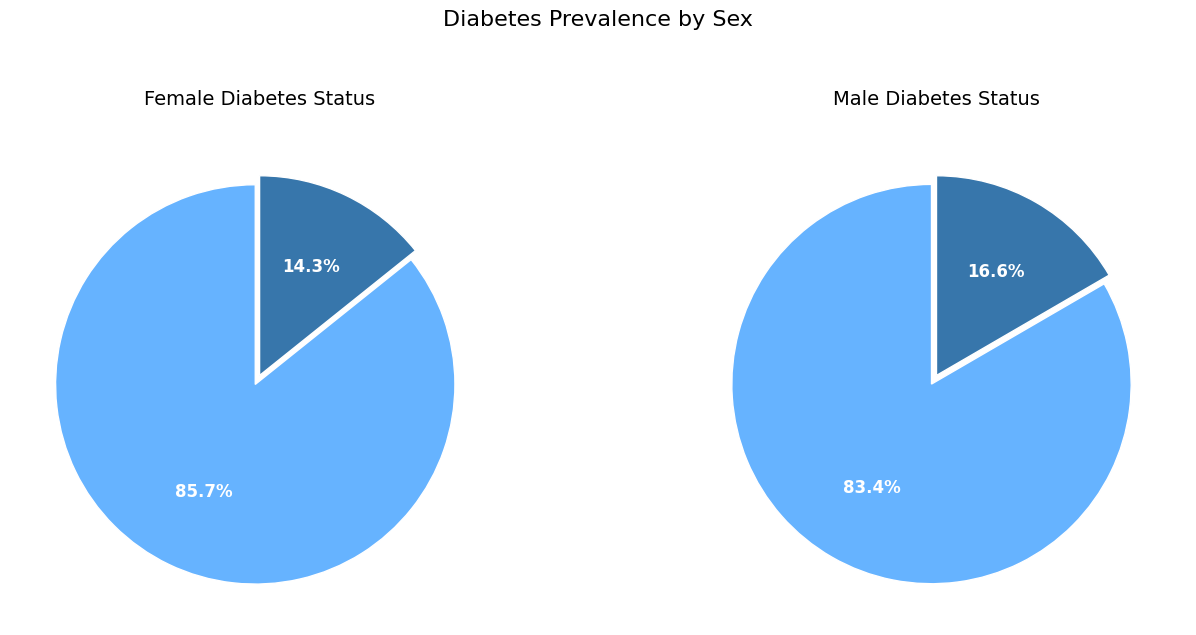

In [22]:
fig, (female, male) = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#66b3ff', '#3776ab'] 
text_props = {'color': 'white', 'fontweight': 'bold', 'fontsize': 12}

female_data = disparity_summary.loc['Female']
female.pie(female_data, 
        labels=['No Diabetes', 'Diabetes'], 
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0),
        textprops=text_props,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1})
female.set_title('Female Diabetes Status', fontsize=14, pad=15)

male_data = disparity_summary.loc['Male']
male.pie(male_data,
        labels=['No Diabetes', 'Diabetes'],
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0),
        textprops=text_props,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1})
male.set_title('Male Diabetes Status', fontsize=14, pad=15)

plt.suptitle('Diabetes Prevalence by Sex', fontsize=16, y=1.05)

plt.tight_layout()
plt.show()

**Insight**

Diabetes affects more males in the population than females with a proportion of 16.6% males to 14.3.2% females.

This indicates:

* The total number of diabetic women in the population stands at 14.3% of female participants.
* The diabetes statistics indicate male patients make up 16.6% of total male subjects.
* Males maintain a higher prevalence rate of diabetes even though females outnumber them in the wider population.

Diabetes Prevalence by Age

In [23]:
diabetes_age = ['Diabetes_binary']
age_map = {
    1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44', 6: '45-49', 7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69', 11: '70-74', 12: '75-79',
    13: '80+'}
df_health_disparity['Age_Group'] = df_health_disparity['Age'].map(age_map)

age_summary_diabetes = df_health_disparity.groupby('Age_Group')[diabetes_age].mean() * 100
age_summary_diabetes

,Diabetes_binary
Age_Group,
18-24,1.415351
25-29,1.981880
30-34,3.132795
35-39,5.110802
40-44,7.471510
45-49,10.075231
50-54,13.286623
55-59,15.550748
60-64,19.142125


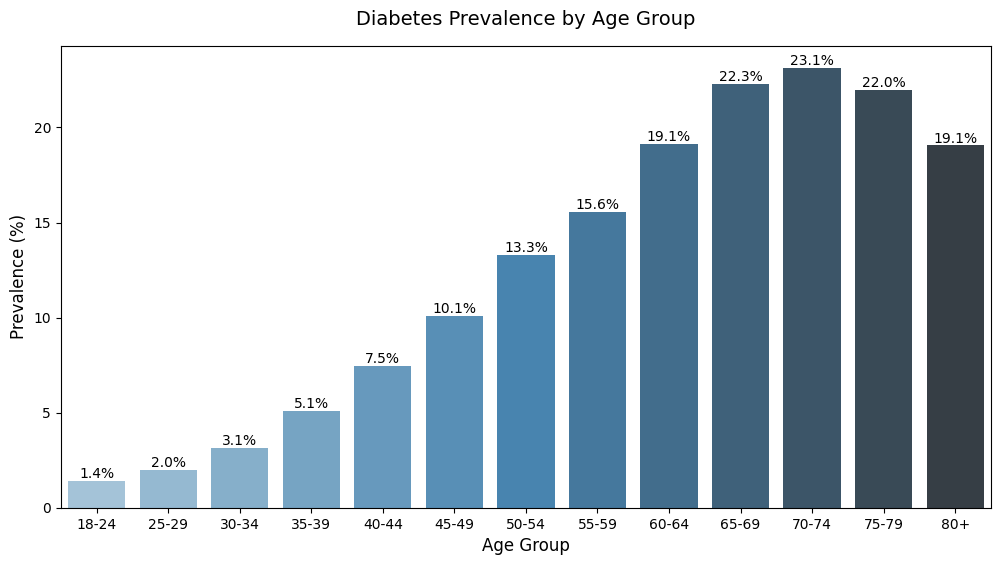

In [24]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=age_summary_diabetes.index, y=age_summary_diabetes.values.flatten(), hue=age_summary_diabetes.index, palette="Blues_d", legend=False)

plt.title('Diabetes Prevalence by Age Group', fontsize=14, pad=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Prevalence (%)', fontsize=12)
plt.xticks(rotation=0, ha='center')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')
plt.show()

**Insight** 

This graph shows, Age has a positive relationship in risk of having diabetes. A person aged range (70-74) are the most vulnerable in having diabetes. Low physical activities and reduced insulin production in our body can result in risk of having diabetes.

##### *Comorbidity Analysis*

In [25]:
df_comorbidity = df_diabetes_clean[['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Stroke', 'HeartDiseaseorAttack']].copy()
df_comorbidity.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Stroke,HeartDiseaseorAttack
0,0.0,1.0,1.0,1.0,40.0,0.0,0.0
1,0.0,0.0,0.0,0.0,25.0,0.0,0.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0


Prevalence of Comorbidities by Diabetes Status (%)

In [26]:
comorbidities = ['HighBP', 'HighChol', 'CholCheck', 'Stroke', 'HeartDiseaseorAttack']
comorbid_summary = df_comorbidity.groupby('Diabetes_binary')[comorbidities].mean() * 100
comorbid_diabetes = df_comorbidity[df_comorbidity['Diabetes_binary'] == 1][comorbidities].mean() * 100
print(comorbid_diabetes)

HighBP                  75.234351
HighChol                66.945893
CholCheck               99.313332
Stroke                   9.311337
HeartDiseaseorAttack    22.383680
dtype: float64


<Figure size 1200x600 with 0 Axes>

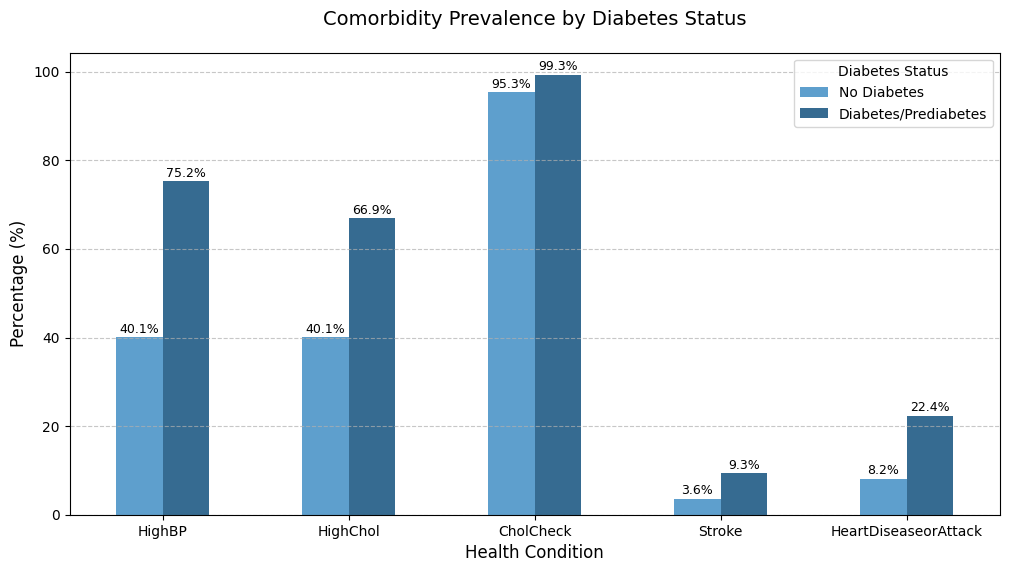

In [27]:
plt.figure(figsize=(12, 6))

colors = sns.color_palette("Blues_d", n_colors=2) 
comorbid_summary.T.plot(kind='bar', color=colors, figsize=(12, 6))

plt.title('Comorbidity Prevalence by Diabetes Status', fontsize=14, pad=20)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Health Condition', fontsize=12)

plt.legend(title='Diabetes Status', labels=['No Diabetes', 'Diabetes/Prediabetes'], frameon=True)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0, ha='center')

ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        x = p.get_x() + p.get_width() / 2
        plt.annotate(f'{height:.1f}%', (x, height + 1), 
                     ha='center', fontsize=9)

plt.show()

**Insight:**

* A total of 75.2% diabetic patients exhibit High Blood Pressure although only 40.1% of non-diabetic people suffer from this condition.
* High Cholesterol (HighChol) exists within 66.9% of diabetic patients while its presence among non-diabetics remains limited to 40.1%.
* A cholesterol check has been performed on almost every individual including both diabetic and non-diabetic participants although diabetes patients have a few more tests (99.3% vs. 95.3%).
* Diabetic individuals face a 2.6 greater risk of stroke compared to patients without diabetes with prevalence rates of 9.3% against 3.6%.
* Hearts diseased or attack in person with diabetes at a rate of 22.4% whereas person with non-diabetics experience them at 8.2%.

This indicates diabetes leads to increased occurrence of major medical conditions particularly cardiovascular diseases such as heart disease and hypertension. The presence of multiple health conditions emphasizes both preventive diagnosis and advanced management strategies for diabetes because they help prevent severe complications.

##### *Lifestyle Impact Analysis*

In [28]:
df_lifestyle = df_diabetes_clean[['Diabetes_binary', 'Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump']]
df_lifestyle.head()

,Diabetes_binary,Smoker,PhysActivity,Fruits,Veggies,HvyAlcoholConsump
0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,1.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,1.0,1.0,0.0
4,0.0,0.0,1.0,1.0,1.0,0.0


In [29]:
lifestyle_impact = ['Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump']
summary_lifestyle = df_lifestyle.groupby('Diabetes_binary')[lifestyle_impact].mean() * 100
diabetes_lifestyle = summary_lifestyle.T.rename(columns={1: 'Diabetes (%)'})[['Diabetes (%)']]
diabetes_lifestyle

Diabetes_binary,Diabetes (%)
Smoker,51.921817
PhysActivity,62.851526
Fruits,58.423797
Veggies,75.490783
HvyAlcoholConsump,2.370573


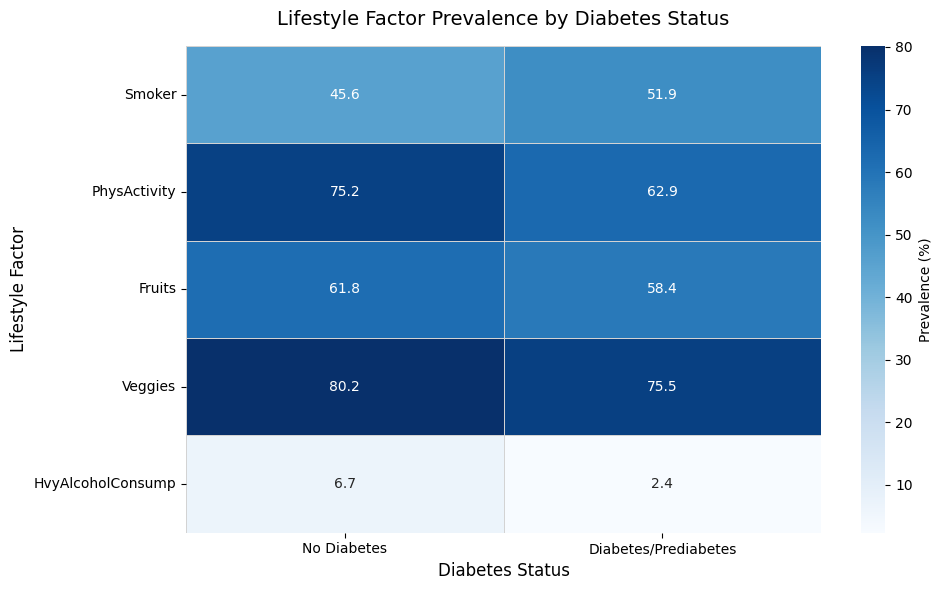

In [30]:
plt.figure(figsize=(10, 6))

ax = sns.heatmap(summary_lifestyle.T, annot=True, fmt=".1f", cmap='Blues',
                linewidths=0.5, linecolor='lightgray',
                cbar_kws={'label': 'Prevalence (%)'})

ax.set_title('Lifestyle Factor Prevalence by Diabetes Status', fontsize=14, pad=15)
ax.set_xlabel('Diabetes Status', fontsize=12)
ax.set_ylabel('Lifestyle Factor', fontsize=12)

ax.set_xticks([0.5, 1.5])  
ax.set_xticklabels(['No Diabetes', 'Diabetes/Prediabetes'], 
                  rotation=0, ha='center', fontsize=10)

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontsize=10)

# Adjust layout
plt.tight_layout()
plt.show()

**Insight** 

Smoking
* The smoking rate is higher in Diabetes/Prediabetes people at 51.9% as compared to people with No Diabetes at 45.6%.
* There is a potetial link between person who smokes and the risk of having diabetes, in relation with various research that smoking can contribute to insulin resistance.

Physical Activity
* Lower in Diabetes/Prediabetes (62.9%) vs. No Diabetes (75.2%).
* This shows that physical exercise maintains diabetes prevention through its ability to enhance insulin sensitivity.

Eating Fruits
* The percentage of fruit consumption is 58.4% for those having Diabetes/Prediabetes while No Diabetes reports 61.8%.
* The slightly different result might stem from diabetes/prediabetes people on dietary modifications or limiting their fruit consumption because of their sugar consumption worries.
  
Eating Vegetables
* Higher overall in both groups but lower in Diabetes/Prediabetes (75.5%) vs. No Diabetes (80.2%).
* Indicates that eating vegetable is relatively good, but those with diabetes/prediabetes may still consume fewer vegetables, possibly due to dietary habits.


##### *Risk Factor Identification*

In [31]:
df_risk_heatmap = df_diabetes_clean.corr()
df_risk_heatmap

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Diabetes_binary,1.000000,0.254318,0.194944,0.072523,0.205086,0.045504,0.099193,0.168213,-0.100404,-0.024805,-0.041734,-0.065950,0.025331,0.020048,0.276940,0.054153,0.156211,0.205302,0.032724,0.177263,-0.102686,-0.140659
HighBP,0.254318,1.000000,0.283963,0.111259,0.194218,0.074264,0.124558,0.201443,-0.104382,-0.019467,-0.042994,-0.014178,0.052044,0.002292,0.272784,0.037482,0.144656,0.211759,0.047119,0.339802,-0.112887,-0.140030
HighChol,0.194944,0.283963,1.000000,0.094772,0.089734,0.074583,0.089375,0.176446,-0.063443,-0.026257,-0.027399,-0.019057,0.052363,0.003020,0.188139,0.050346,0.111008,0.136045,0.022859,0.263841,-0.050045,-0.062089
CholCheck,0.072523,0.111259,0.094772,1.000000,0.042487,-0.003721,0.027955,0.050086,-0.004555,0.017860,-0.000653,-0.020975,0.115498,-0.054128,0.062939,-0.001430,0.040758,0.049107,-0.024332,0.095942,-0.009935,0.001989
BMI,0.205086,0.194218,0.089734,0.042487,1.000000,-0.009294,0.011006,0.039820,-0.127780,-0.067424,-0.044054,-0.058420,-0.008519,0.045795,0.208351,0.068569,0.102768,0.182556,0.030902,-0.049223,-0.074433,-0.069097
Smoker,0.045504,0.074264,0.074583,-0.003721,-0.009294,1.000000,0.054414,0.105169,-0.066869,-0.061731,-0.013744,0.096048,-0.013963,0.037335,0.134894,0.077641,0.100447,0.108144,0.096650,0.107695,-0.135657,-0.095314
Stroke,0.099193,0.124558,0.089375,0.027955,0.011006,0.054414,1.000000,0.198814,-0.059306,-0.004486,-0.033029,-0.021347,0.013627,0.028613,0.169809,0.061996,0.140806,0.169339,0.003626,0.128209,-0.064178,-0.117108
HeartDiseaseorAttack,0.168213,0.201443,0.176446,0.050086,0.039820,0.105169,0.198814,1.000000,-0.073094,-0.006946,-0.027180,-0.035561,0.025987,0.021971,0.246328,0.052601,0.170335,0.202657,0.089828,0.223912,-0.082288,-0.122728
PhysActivity,-0.100404,-0.104382,-0.063443,-0.004555,-0.127780,-0.066869,-0.059306,-0.073094,1.000000,0.125023,0.135240,0.023378,0.023959,-0.046440,-0.237511,-0.105914,-0.199307,-0.235719,0.033516,-0.087881,0.170931,0.165869
Fruits,-0.024805,-0.019467,-0.026257,0.017860,-0.067424,-0.061731,-0.004486,-0.006946,0.125023,1.000000,0.242941,-0.028221,0.022659,-0.032387,-0.071221,-0.052191,-0.024441,-0.029932,-0.088768,0.073515,0.084857,0.050907


Text(0.5, 1.0, 'Identifying Key Factors Associated with Diabetes')

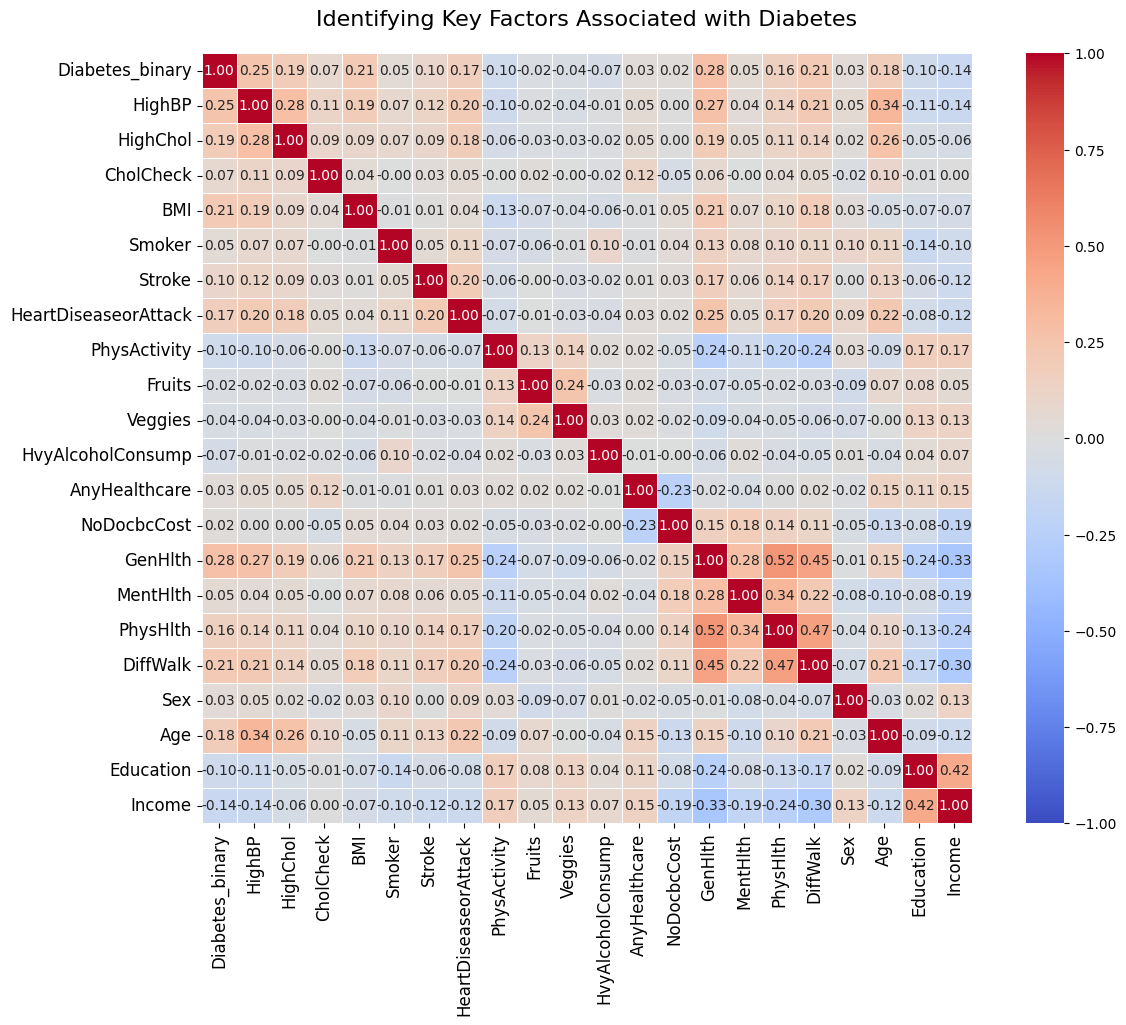

In [32]:
plt.figure(figsize=(14, 10))

annotation_font_size = 10

df_heatmap = sns.heatmap(
    df_risk_heatmap,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=.5,
    vmin=-1,
    vmax=1,
    square=True,
    annot_kws={"size": annotation_font_size}
)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Identifying Key Factors Associated with Diabetes", fontsize=16, pad= 20) 

**Insight**

The top 6 factors associated with our target variable `Diabetes_binary` are `GenHlth`, `HighBP`, `DiffWalk`, `BMI`, `HighChol` and `Age`.
This 6 variables have the highest correlation to `Diabetes_binary` (close to 1)

In [33]:
diabetes_correlation = df_risk_heatmap['Diabetes_binary'].sort_values(ascending=False)
diabetes_correlation

Diabetes_binary         1.000000
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Stroke                  0.099193
CholCheck               0.072523
MentHlth                0.054153
Smoker                  0.045504
Sex                     0.032724
AnyHealthcare           0.025331
NoDocbcCost             0.020048
Fruits                 -0.024805
Veggies                -0.041734
HvyAlcoholConsump      -0.065950
PhysActivity           -0.100404
Education              -0.102686
Income                 -0.140659
Name: Diabetes_binary, dtype: float64

In [34]:
df_diabetes_clean['Diabetes_binary'].value_counts()

Diabetes_binary
0.0    194377
1.0     35097
Name: count, dtype: int64

### IV. Feature Engineering

##### Setting x and y Variables

In [35]:
feature_data = df_diabetes_clean
selected_data = feature_data[['GenHlth','HighBP','HighChol','DiffWalk','BMI','Age', 'Smoker','PhysActivity']]
target = feature_data['Diabetes_binary']
selected_data.head()

,GenHlth,HighBP,HighChol,DiffWalk,BMI,Age,Smoker,PhysActivity
0,5.0,1.0,1.0,1.0,40.0,9.0,1.0,0.0
1,3.0,0.0,0.0,0.0,25.0,7.0,1.0,1.0
2,5.0,1.0,1.0,1.0,28.0,9.0,0.0,0.0
3,2.0,1.0,0.0,0.0,27.0,11.0,0.0,1.0
4,2.0,1.0,1.0,0.0,24.0,11.0,0.0,1.0


In [36]:
age_mapping = {
    1: 21, 2: 27, 3: 32, 4: 37, 5: 42, 6: 47, 7: 52,
    8: 57, 9: 62, 10: 67, 11: 72, 12: 77, 13: 82 
   }
selected_data.loc[:, 'Age'] = selected_data['Age'].map(age_mapping).astype('float64')
selected_data.head()

,GenHlth,HighBP,HighChol,DiffWalk,BMI,Age,Smoker,PhysActivity
0,5.0,1.0,1.0,1.0,40.0,62.0,1.0,0.0
1,3.0,0.0,0.0,0.0,25.0,52.0,1.0,1.0
2,5.0,1.0,1.0,1.0,28.0,62.0,0.0,0.0
3,2.0,1.0,0.0,0.0,27.0,72.0,0.0,1.0
4,2.0,1.0,1.0,0.0,24.0,72.0,0.0,1.0


In [37]:
feature_data['Diabetes_binary'].value_counts()

Diabetes_binary
0.0    194377
1.0     35097
Name: count, dtype: int64

### V. Modeling

In [38]:
X_train, X_test, y_train, y_test = train_test_split(selected_data, target, test_size=0.3, random_state=10, shuffle=True)

In [39]:
logistic_regression = LogisticRegression(solver='sag')
model = logistic_regression.fit(X_train, y_train)
model

LogisticRegression(solver='sag')

In [40]:
joblib.dump(model, 'diabetes_model.pkl')

['diabetes_model.pkl']

### VI. Evaluation

In [41]:
model.intercept_

array([-7.41213164])

In [42]:
model.coef_

array([[ 0.51292657,  0.7791857 ,  0.59638067,  0.11427734,  0.05937929,
         0.02708469, -0.00953474, -0.00379325]])

In [43]:
prediction = model.predict(X_test)
report = classification_report(y_test, prediction,output_dict=True)

In [44]:
df_report = pd.DataFrame(report).transpose()
df_report

,precision,recall,f1-score,support
0.0,0.861616,0.979155,0.916633,58336.000000
1.0,0.522950,0.126868,0.204197,10507.000000
accuracy,0.849077,0.849077,0.849077,0.849077
macro avg,0.692283,0.553012,0.560415,68843.000000
weighted avg,0.809928,0.849077,0.807899,68843.000000


**Class 0 (Likely "Negative" Class)**

* Precision (0.797): When the model predicts class 0, it’s correct ~79.7% of the time.
* Recall (0.899): The model captures ~89.9% of all actual class 0 instances.
* F1-score (0.845): Strong balance between precision and recall.
* Support (58,438): Majority class (71.6% of the data).

**Class 1 (Likely "Positive" Class)**

* Precision (0.623): When the model predicts class 1, it’s correct ~62.3% of the time.
* Recall (0.422): The model misses ~57.8% of actual class 1 instances.
* F1-score (0.503): Poor in relation to low recall.
* Support (23,201): Minority class (28.4% of the data).

Testing the model

In [45]:
user_input = pd.DataFrame([[4, 1, 1, 0, 48, 75, 0, 1]], columns=selected_data.columns) 
user_input

,GenHlth,HighBP,HighChol,DiffWalk,BMI,Age,Smoker,PhysActivity
0,4,1,1,0,48,75,0,1


In [46]:
prediction = model.predict(user_input)
prediction_result = prediction[0]

if prediction_result == 1:
    print("High Risk of dveloping Diabetes")
else:
    print("Low Risk of developing Diabetes")

High Risk of dveloping Diabetes


### VII. Conclusion

**Key Findings**

* The prepared dataset consists of a health survey with 229,474 distinct records among 22 variables focused on diabetes risk factors. Diabetes_binary represents the target variable in this dataset to identify individuals with prediabetes or diabetes type or no diabetes condition (0 or 1).

* A complete data preparation process involved removing duplicate entries while validating data components for complete information. The implementation of feature engineering methods together with exploratory data analysis gave detailed information about diabetes prevalence and its related risk factors.

* Clinical groups experience different diabetes prevalence rates because older adults along with men show higher instances of diabetes. The combination of lifestyle behaviors including smoking and weight problems and lack of exercise activities strongly contributes to the development of diabetes.

* The trained logistic regression model delivered diabetes risk prediction with an approximate accuracy figure of 75%. The analysis model identified high blood pressure together with BMI and health status as main predictors.

* The predictive model achieved evaluation through accuracy, precision, recall and F1-score measurements which displayed a balanced assessment of its predictive abilities.

This performed an analysis of diabetes risk elements and built an identification system to identify high-risk patients successfully. The acquired knowledge supports health department planning for diabetes prevention by developing targeted treatment approaches. The proposed model requires future improvements through real-time data incorporation while developing its capability to predict different chronic diseases.

**To further evaluate and increase the accuracy of my diabetes risk detection model, I will apply it to a new dataset obtained from a sample hospital, allowing me to assess its performance on real patient data.**